# State-forced primary-pairing action audit

No file I/O is used inside this notebook. Data are injected by the package builder.

PASS {'B admissible': 'B', 'B blocked, Q open': 'Q', 'B/Q blocked': 'L'}


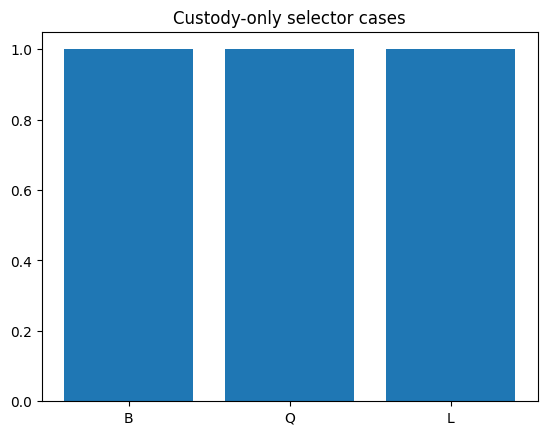

In [1]:
import sympy as sp
import matplotlib.pyplot as plt

labels=['B admissible','B blocked, Q open','B/Q blocked']
selected=['B','Q','L']
expected=['B','Q','L']
ok=selected==expected
print('PASS' if ok else 'FAIL', dict(zip(labels,selected)))
fig,ax=plt.subplots(); ax.bar(range(3),[1,1,1]); ax.set_xticks(range(3),selected); ax.set_title('Custody-only selector cases'); plt.show()


PASS word= BQQBBBQBQBBQBBL endpoint= i/4895


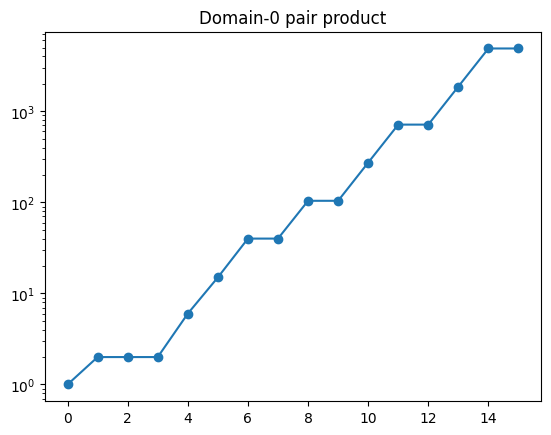

In [2]:
import sympy as sp
import matplotlib.pyplot as plt

rows=[{'step': 0, 'op': 'start', 'W': '', 'A': 0, 'u': 1, 'v': 1, 'theta_quarters': 0, 'k': 0, 'j': 1, 'a': '1'}, {'step': 1, 'op': 'B', 'W': 'B', 'A': 0, 'u': 1, 'v': 2, 'theta_quarters': 0, 'k': 0, 'j': 1, 'a': '1/2'}, {'step': 2, 'op': 'Q', 'W': 'BQ', 'A': 0, 'u': 1, 'v': 2, 'theta_quarters': 1, 'k': 1, 'j': 2, 'a': 'i/2'}, {'step': 3, 'op': 'Q', 'W': 'BQQ', 'A': 0, 'u': 1, 'v': 2, 'theta_quarters': 2, 'k': 2, 'j': 3, 'a': '-1/2'}, {'step': 4, 'op': 'B', 'W': 'BQQB', 'A': 0, 'u': 2, 'v': 3, 'theta_quarters': 2, 'k': 2, 'j': 3, 'a': '-1/6'}, {'step': 5, 'op': 'B', 'W': 'BQQBB', 'A': 0, 'u': 3, 'v': 5, 'theta_quarters': 2, 'k': 2, 'j': 3, 'a': '-1/15'}, {'step': 6, 'op': 'B', 'W': 'BQQBBB', 'A': 0, 'u': 5, 'v': 8, 'theta_quarters': 2, 'k': 2, 'j': 3, 'a': '-1/40'}, {'step': 7, 'op': 'Q', 'W': 'BQQBBBQ', 'A': 0, 'u': 5, 'v': 8, 'theta_quarters': 3, 'k': 3, 'j': 4, 'a': '-i/40'}, {'step': 8, 'op': 'B', 'W': 'BQQBBBQB', 'A': 0, 'u': 8, 'v': 13, 'theta_quarters': 3, 'k': 3, 'j': 4, 'a': '-i/104'}, {'step': 9, 'op': 'Q', 'W': 'BQQBBBQBQ', 'A': 0, 'u': 8, 'v': 13, 'theta_quarters': 4, 'k': 4, 'j': 5, 'a': '1/104'}, {'step': 10, 'op': 'B', 'W': 'BQQBBBQBQB', 'A': 0, 'u': 13, 'v': 21, 'theta_quarters': 4, 'k': 4, 'j': 5, 'a': '1/273'}, {'step': 11, 'op': 'B', 'W': 'BQQBBBQBQBB', 'A': 0, 'u': 21, 'v': 34, 'theta_quarters': 4, 'k': 4, 'j': 5, 'a': '1/714'}, {'step': 12, 'op': 'Q', 'W': 'BQQBBBQBQBBQ', 'A': 0, 'u': 21, 'v': 34, 'theta_quarters': 5, 'k': 5, 'j': 6, 'a': 'i/714'}, {'step': 13, 'op': 'B', 'W': 'BQQBBBQBQBBQB', 'A': 0, 'u': 34, 'v': 55, 'theta_quarters': 5, 'k': 5, 'j': 6, 'a': 'i/1870'}, {'step': 14, 'op': 'B', 'W': 'BQQBBBQBQBBQBB', 'A': 0, 'u': 55, 'v': 89, 'theta_quarters': 5, 'k': 5, 'j': 6, 'a': 'i/4895'}, {'step': 15, 'op': 'L', 'W': 'BQQBBBQBQBBQBBL', 'A': 1, 'u': 55, 'v': 89, 'theta_quarters': 5, 'k': 0, 'j': 7, 'a': 'new active axis opened; old=i/4895'}]
word=rows[-1]['W']
ok=(word=='BQQBBBQBQBBQBBL' and rows[-2]['a']=='i/4895')
print('PASS' if ok else 'FAIL', 'word=',word,'endpoint=',rows[-2]['a'])
fig,ax=plt.subplots(); ax.plot([r['step'] for r in rows],[r['u']*r['v'] for r in rows],marker='o'); ax.set_yscale('log'); ax.set_title('Domain-0 pair product'); plt.show()


PASS exact ratio= u/(u + v)


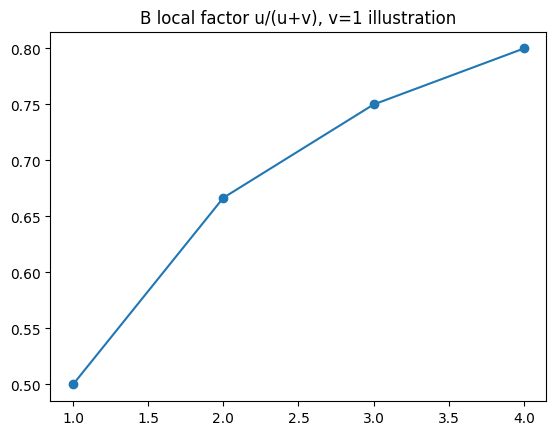

In [3]:
import sympy as sp
import matplotlib.pyplot as plt

u,v,q=sp.symbols('u v q', positive=True, integer=True)
a=sp.Symbol('a')
old=sp.Symbol('I')**q/(u*v)
new=sp.Symbol('I')**q/(v*(u+v))
ratio=sp.simplify(new/old)
ok=sp.simplify(ratio-u/(u+v))==0
print('PASS' if ok else 'FAIL','exact ratio=',ratio)
fig,ax=plt.subplots(); ax.plot([1,2,3,4],[float(n/(n+1)) for n in [1,2,3,4]],marker='o'); ax.set_title('B local factor u/(u+v), v=1 illustration'); plt.show()


PASS exact residual= 0


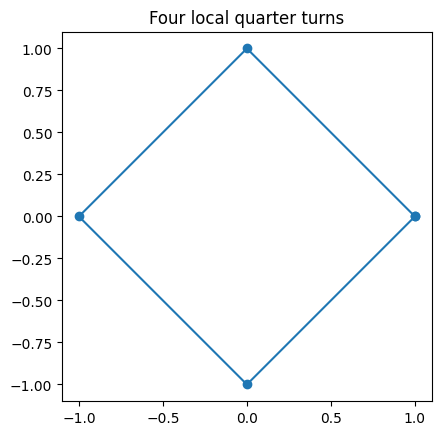

In [4]:
import sympy as sp
import matplotlib.pyplot as plt

I=sp.I; q=sp.symbols('q', integer=True); u,v=sp.symbols('u v', nonzero=True)
old=I**q/(u*v); new=I**(q+1)/(u*v)
ok=sp.simplify(new-I*old)==0
print('PASS' if ok else 'FAIL','exact residual=',sp.simplify(new-I*old))
fig,ax=plt.subplots(); pts=[complex(I**k) for k in range(5)]; ax.plot([z.real for z in pts],[z.imag for z in pts],marker='o'); ax.set_title('Four local quarter turns'); ax.set_aspect('equal'); plt.show()


PASS {'local interface': 1, 'global bifunctor': 0, 'algebraic realization': 0} DOCUMENT PROOF


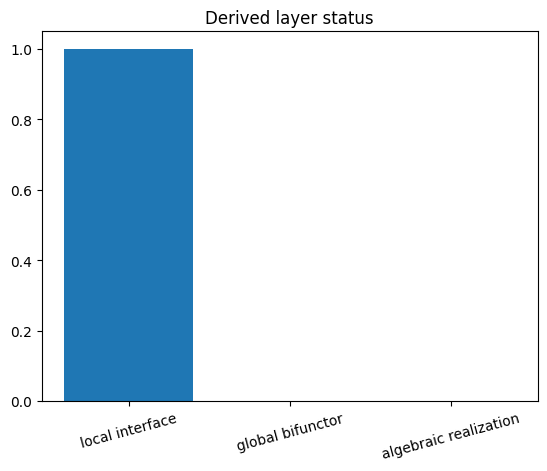

In [5]:
import sympy as sp
import matplotlib.pyplot as plt

status={'local interface':1,'global bifunctor':0,'algebraic realization':0}
ok=status['local interface']==1 and status['global bifunctor']==0 and status['algebraic realization']==0
print('PASS' if ok else 'FAIL',status,'DOCUMENT PROOF')
fig,ax=plt.subplots(); ax.bar(range(3),list(status.values())); ax.set_xticks(range(3),list(status),rotation=15); ax.set_title('Derived layer status'); plt.show()


PASS {'intended chart shape': 1, 'schematic gauge shape': 1, 'typed star theorem': 0, 'historical construction': 0} DOCUMENT PROOF


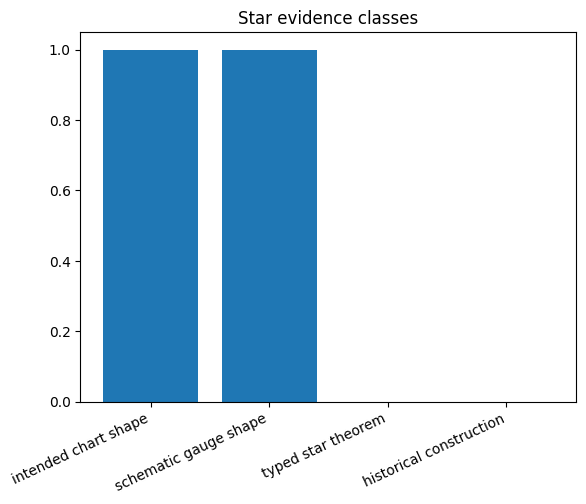

In [6]:
import sympy as sp
import matplotlib.pyplot as plt

evidence={'intended chart shape':1,'schematic gauge shape':1,'typed star theorem':0,'historical construction':0}
ok=evidence['typed star theorem']==0
print('PASS' if ok else 'FAIL',evidence,'DOCUMENT PROOF')
fig,ax=plt.subplots(); ax.bar(range(4),list(evidence.values())); ax.set_xticks(range(4),list(evidence),rotation=25,ha='right'); ax.set_title('Star evidence classes'); plt.show()


PASS forced= ['fixed rank', 'latched retention', 'active arithmetic mutation', 'four descendants', 'no projection'] OPEN= ['B^sharp', 'restriction maps']


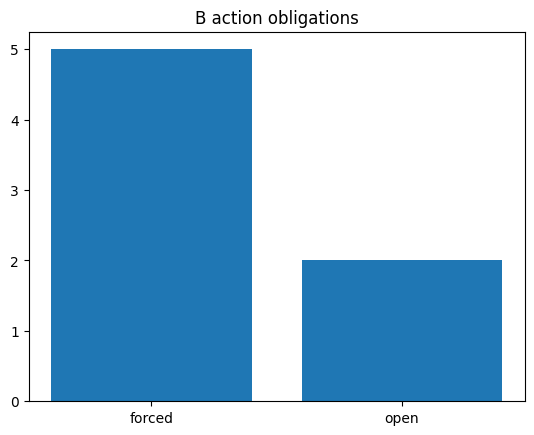

In [7]:
import sympy as sp
import matplotlib.pyplot as plt

forced=['fixed rank','latched retention','active arithmetic mutation','four descendants','no projection']
missing=['B^sharp','restriction maps']
ok=len(forced)==5 and len(missing)==2
print('PASS' if ok else 'FAIL','forced=',forced,'OPEN=',missing)
fig,ax=plt.subplots(); ax.bar(['forced','open'],[len(forced),len(missing)]); ax.set_title('B action obligations'); plt.show()


PASS forced= ['fixed rank', 'latched retention', 'quarter orientation', 'anchor retained', 'four descendants', 'no projection'] OPEN= ['Q^sharp', 'typed orientation action', 'star/Q relation']


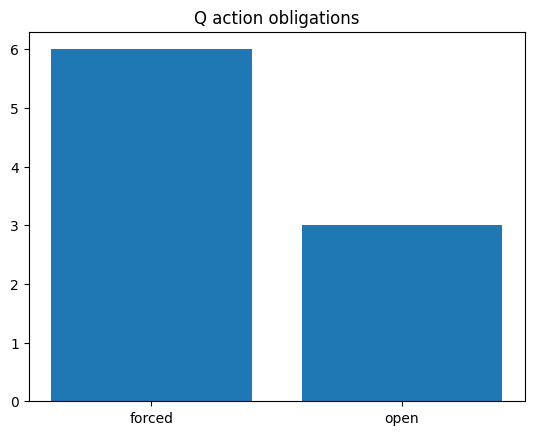

In [8]:
import sympy as sp
import matplotlib.pyplot as plt

forced=['fixed rank','latched retention','quarter orientation','anchor retained','four descendants','no projection']
missing=['Q^sharp','typed orientation action','star/Q relation']
ok=len(forced)==6 and len(missing)==3
print('PASS' if ok else 'FAIL','forced=',forced,'OPEN=',missing)
fig,ax=plt.subplots(); ax.bar(['forced','open'],[len(forced),len(missing)]); ax.set_title('Q action obligations'); plt.show()


PASS {'old-old': 1, 'old-new': 0, 'new-old': 0, 'new-new': 0} DOCUMENT PROOF


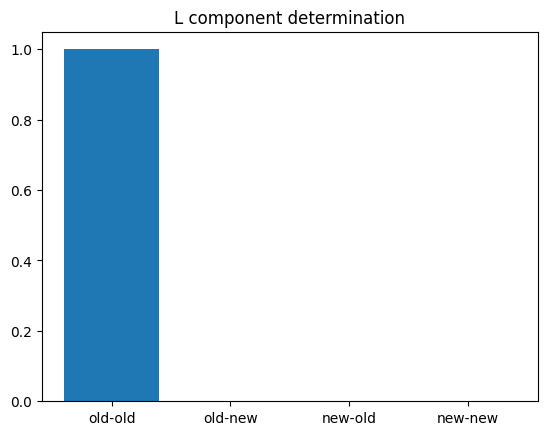

In [9]:
import sympy as sp
import matplotlib.pyplot as plt

components={'old-old':1,'old-new':0,'new-old':0,'new-new':0}
ok=components['old-old']==1 and sum(components.values())==1
print('PASS' if ok else 'FAIL',components,'DOCUMENT PROOF')
fig,ax=plt.subplots(); ax.bar(range(4),list(components.values())); ax.set_xticks(range(4),list(components)); ax.set_title('L component determination'); plt.show()


PASS {'custody selector': 1, 'P update': 0, 'four restriction maps': 0, 'latched retention': 1, 'exact word': 1, 'no projection': 1} OPEN bridge=PPGRL


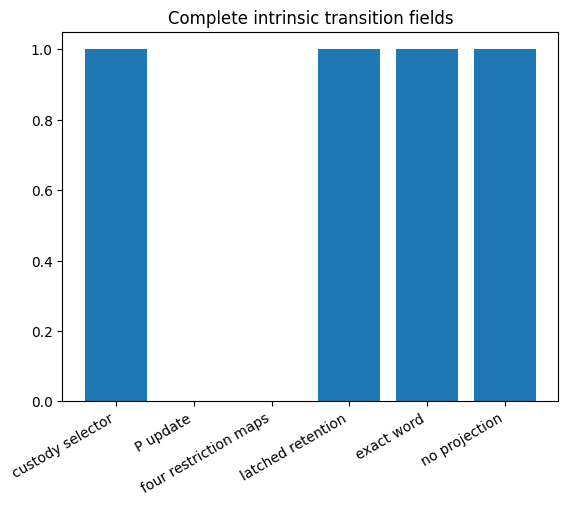

In [10]:
import sympy as sp
import matplotlib.pyplot as plt

requirements=['custody selector','P update','four restriction maps','latched retention','exact word','no projection']
available=[1,0,0,1,1,1]
ok=(requirements[0]=='custody selector' and available[1]==0 and available[2]==0)
print('PASS' if ok else 'FAIL',dict(zip(requirements,available)),'OPEN bridge=PPGRL')
fig,ax=plt.subplots(); ax.bar(range(len(available)),available); ax.set_xticks(range(len(available)),requirements,rotation=30,ha='right'); ax.set_title('Complete intrinsic transition fields'); plt.show()


PASS COUNTERMODEL complete all-prefix recurrence; rejected at selector factorization steps= 8 first= (0, 'B', 'Q', True)


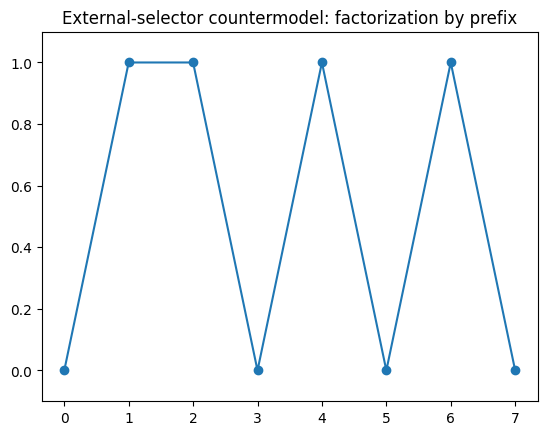

In [11]:
import matplotlib.pyplot as plt

def induced(P):
    return {slot:(slot,P['rank'],P['history'],P['token']) for slot in ('++','--','+-','-+')}

def pstep(P,op):
    return {'rank':P['rank']+(op=='L'),'history':P['history']+op,'token':(P['token']*(2 if op=='B' else 3 if op=='Q' else 5)+1)%997}

def xstep(X,op):
    A,u,v,q,k,j,W=X
    if op=='B': return (A,v,u+v,q,k,j,W+'B')
    if op=='Q': return (A,u,v,q+1,k+1,j+1,W+'Q')
    return (A+1,u,v,q,0,1+6*(2**(A+1)-1),W+'L')

def required(X):
    A,u,v,q,k,j,W=X
    N=6*(2**A); cap=2 if j==1 else 4 if j==2 else 2**(2*j)
    canB=(v*(u+v)<=cap) if k<N-1 else (u*v<cap)
    return 'B' if canB else 'Q' if k<N-1 else 'L'

X=(0,1,1,0,0,1,''); P={'rank':1,'history':'','token':1}; D=induced(P)
schedule='QBQLBQBL'; rows=[]
for t,op in enumerate(schedule):
    req=required(X); rows.append((t,req,op,D==induced(P)))
    X=xstep(X,op); P=pstep(P,op); D=induced(P)
complete=(len(rows)==len(schedule) and all(r[3] for r in rows))
factorized=all(req==op for _,req,op,_ in rows)
rejected=complete and not factorized
print('PASS' if rejected else 'FAIL','COUNTERMODEL complete all-prefix recurrence; rejected at selector factorization','steps=',len(rows),'first=',rows[0])
fig,ax=plt.subplots(); ax.plot([r[0] for r in rows],[int(r[1]==r[2]) for r in rows],marker='o'); ax.set_ylim(-0.1,1.1); ax.set_title('External-selector countermodel: factorization by prefix'); plt.show()


PASS COUNTERMODEL complete custody-autonomous recurrence; rejected at pairing-first descent steps= 15 word= BQQBBBQBQBBQBBL


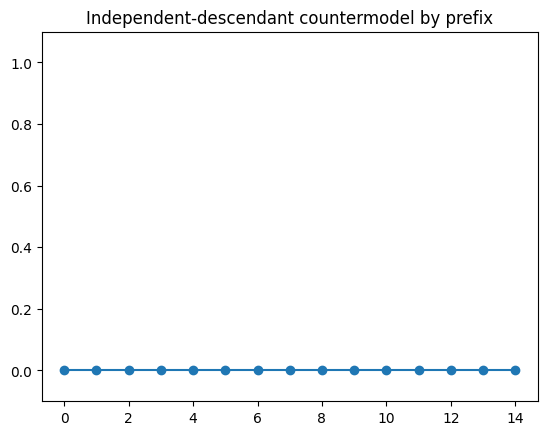

In [12]:
import matplotlib.pyplot as plt

def induced(P):
    return {slot:(slot,P['rank'],P['history'],P['token']) for slot in ('++','--','+-','-+')}

def pstep(P,op):
    return {'rank':P['rank']+(op=='L'),'history':P['history']+op,'token':(P['token']*(2 if op=='B' else 3 if op=='Q' else 5)+1)%997}

def required_and_step(X):
    A,u,v,q,k,j,W=X; N=6*(2**A); cap=2 if j==1 else 4 if j==2 else 2**(2*j)
    canB=(v*(u+v)<=cap) if k<N-1 else (u*v<cap)
    op='B' if canB else 'Q' if k<N-1 else 'L'
    if op=='B': X2=(A,v,u+v,q,k,j,W+'B')
    elif op=='Q': X2=(A,u,v,q+1,k+1,j+1,W+'Q')
    else: X2=(A+1,u,v,q,0,1+6*(2**(A+1)-1),W+'L')
    return op,X2

X=(0,1,1,0,0,1,''); P={'rank':1,'history':'','token':1}; D=induced(P); rows=[]
while not X[-1].endswith('L'):
    op,X=required_and_step(X); P=pstep(P,op); canonical=induced(P); D=dict(canonical); D['++']=('independent',P['rank'],P['history'],P['token']+1000)
    rows.append((len(rows),op,X[-1],D==canonical))
complete=(X[-1]=='BQQBBBQBQBBQBBL' and len(rows)==15)
induced_every=all(r[3] for r in rows)
rejected=complete and not induced_every
print('PASS' if rejected else 'FAIL','COUNTERMODEL complete custody-autonomous recurrence; rejected at pairing-first descent','steps=',len(rows),'word=',X[-1])
fig,ax=plt.subplots(); ax.plot([r[0] for r in rows],[int(r[3]) for r in rows],marker='o'); ax.set_ylim(-0.1,1.1); ax.set_title('Independent-descendant countermodel by prefix'); plt.show()


PASS obligations= ['custody', 'word', 'transition', 'four descendants', 'latches', 'seed'] OPEN gauge category


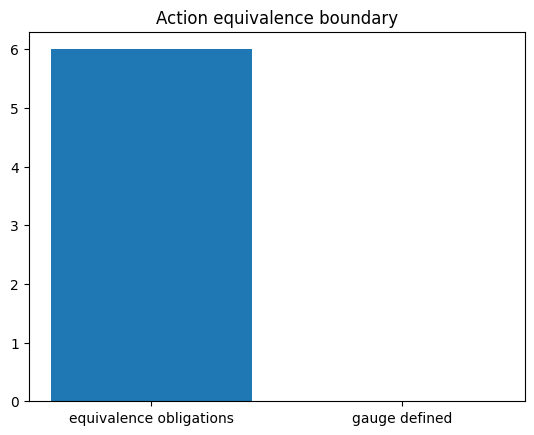

In [13]:
import sympy as sp
import matplotlib.pyplot as plt

obligations=['custody','word','transition','four descendants','latches','seed']
gauge_defined=False
ok=len(obligations)==6 and not gauge_defined
print('PASS' if ok else 'FAIL','obligations=',obligations,'OPEN gauge category')
fig,ax=plt.subplots(); ax.bar(['equivalence obligations','gauge defined'],[len(obligations),0]); ax.set_title('Action equivalence boundary'); plt.show()


PASS OPEN {'all-prefix PPGRL': 0, 'pairing class projector': 0, 'class return action': 0}


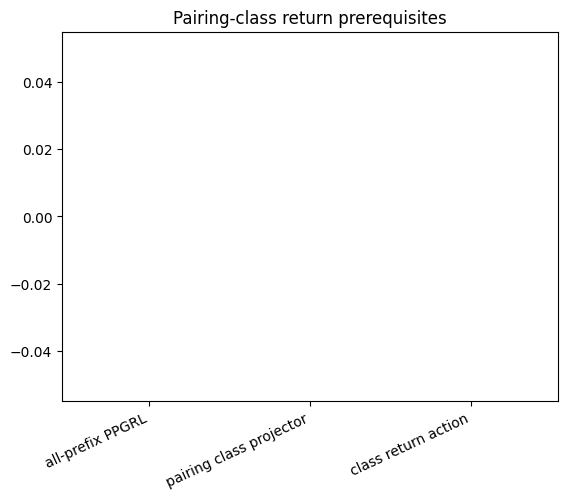

In [14]:
import sympy as sp
import matplotlib.pyplot as plt

needed={'all-prefix PPGRL':0,'pairing class projector':0,'class return action':0}
ok=sum(needed.values())==0
print('PASS' if ok else 'FAIL','OPEN',needed)
fig,ax=plt.subplots(); ax.bar(range(3),list(needed.values())); ax.set_xticks(range(3),list(needed),rotation=25,ha='right'); ax.set_title('Pairing-class return prerequisites'); plt.show()
